In [15]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import pandas as pd
import json

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [16]:
def count_sign_changes(delta_x):
    signs = np.sign(delta_x)
    sign_changes = np.sum(np.diff(signs) != 0)
    return sign_changes

def is_bifurcation(delta_x_list):
    counts = [count_sign_changes(delta_x) for delta_x in delta_x_list]
    unique_counts = set(counts)
    return len(unique_counts) > 1

def metastability_score(f, df, x_grid, tau):
    distance_to_critical = f(x_grid)**2 + df(x_grid)**2
    normalized_distance = distance_to_critical * tau**2 # between 0 (critical) and 1 (linear dynamics)
    return 1-np.min(normalized_distance) 

In [17]:
json_path = cwd / "5CV_Passive_late.json"
with open(json_path, "r") as f:
    data_5cv = json.load(f)
    results_cv = data_5cv.get("results_cv")
    print("Loaded results_cv:", results_cv)

Loaded results_cv: ['NonLinear1', 'NonLinear1', 'NonLinear1', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation']


# Bifurcation Probability & Metastability Scoring 

### Via Particle Density Estimation for the best model **per participant**

Participants:   0%|          | 0/20 [00:00<?, ?it/s]

process_noise = 0.5431, measure_noise = 0.6041, ratio = 0.8990 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.19645876307100074, 
for a real g4 of 0.214856461026499.


Tau grid for part 0:   0%|          | 0/11 [00:00<?, ?it/s]

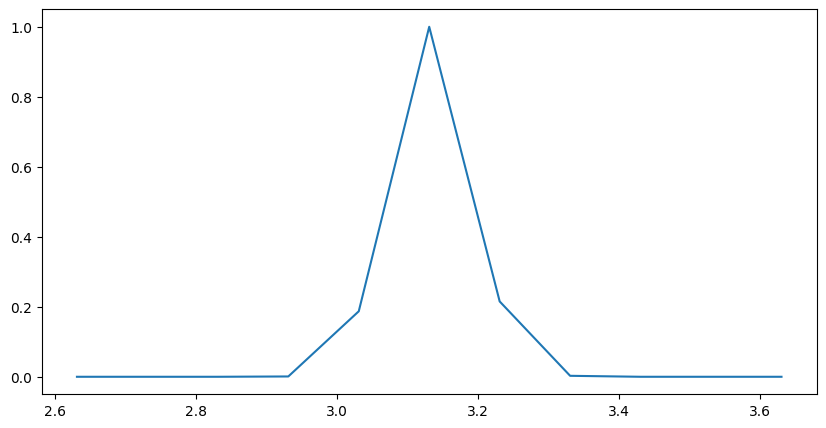

2D Search (Tau) for Part 0: 0it [00:00, ?it/s]

3.030947066439245 is a good enough tau
3.130947066439245 is a good enough tau
3.2309470664392452 is a good enough tau
3.3309470664392453 is a good enough tau
process_noise = 0.5431, measure_noise = 0.5220, ratio = 1.0404 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.2074297664123245, 
for a real g4 of 0.214856461026499.


Tau grid for part 0:   0%|          | 0/11 [00:00<?, ?it/s]

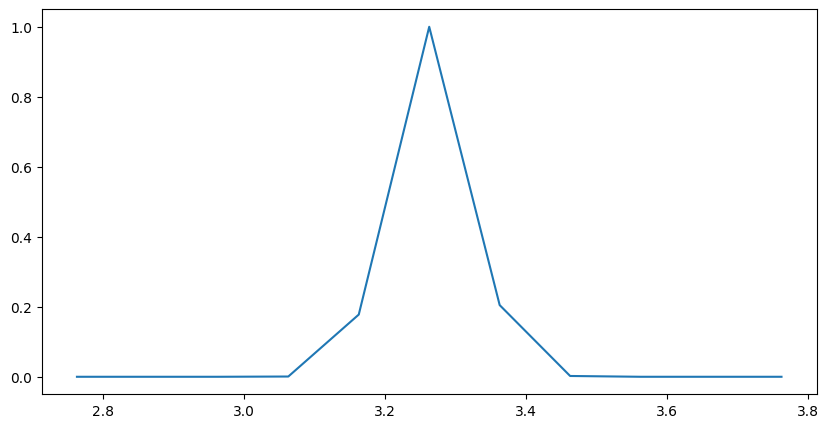

2D Search (Tau) for Part 0: 0it [00:00, ?it/s]

3.1626920454154153 is a good enough tau
3.2626920454154154 is a good enough tau
3.3626920454154154 is a good enough tau
3.4626920454154155 is a good enough tau
process_noise = 0.3654, measure_noise = 1.2728, ratio = 0.2871 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.4488349656833168, 
for a real g4 of 0.1572807470010478.


Tau grid for part 1:   0%|          | 0/11 [00:00<?, ?it/s]

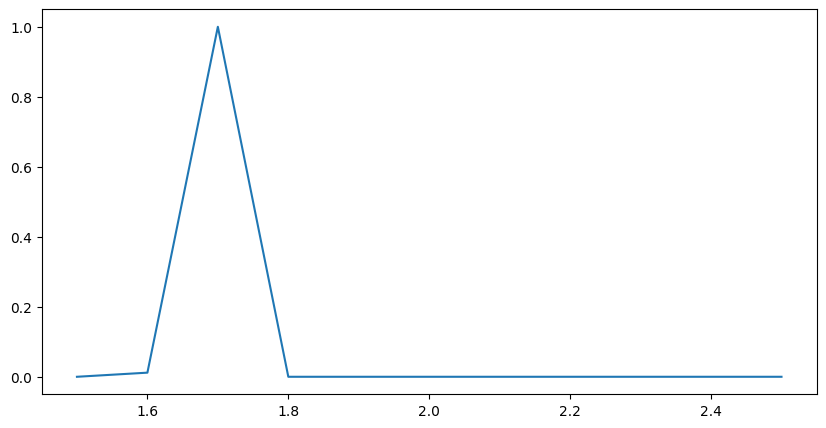

2D Search (Tau) for Part 1: 0it [00:00, ?it/s]

1.6 is a good enough tau
1.7 is a good enough tau
process_noise = 0.3654, measure_noise = 0.6599, ratio = 0.5538 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.1625359108476427, 
for a real g4 of 0.1572807470010478.


Tau grid for part 1:   0%|          | 0/11 [00:00<?, ?it/s]

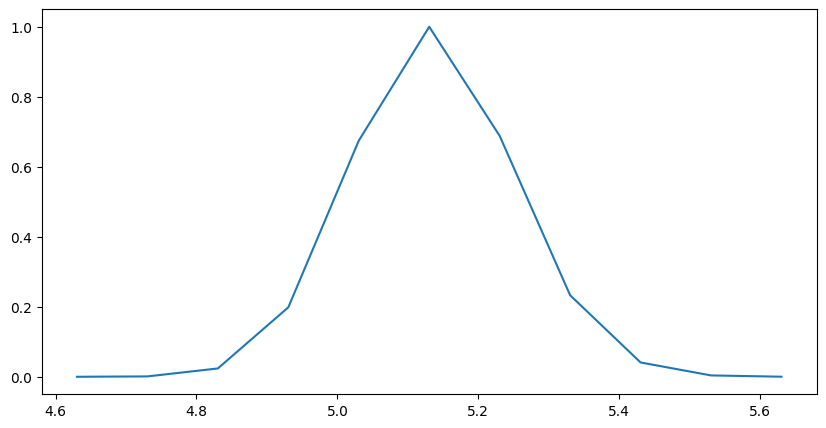

2D Search (Tau) for Part 1: 0it [00:00, ?it/s]

4.730347236871048 is a good enough tau
4.830347236871049 is a good enough tau
4.930347236871048 is a good enough tau
5.030347236871049 is a good enough tau
5.1303472368710485 is a good enough tau
5.230347236871049 is a good enough tau
5.330347236871049 is a good enough tau
5.430347236871048 is a good enough tau
5.530347236871049 is a good enough tau
process_noise = 0.5600, measure_noise = 0.8419, ratio = 0.6653 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.27212252971295164, 
for a real g4 of 0.2726692164624064.


Tau grid for part 2:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
task = "Active"
period = "late"
file_path = Path('MeasureNoiseControl')

# Define the summary path clearly and load existing progress 
summary_path = file_path / "metabifurc_control.csv"
if summary_path.exists():
    control_df = pd.read_csv(summary_path)
    print(f"Found existing summary at {summary_path}, containing {len(control_df)} entries.")
else:
    control_df = pd.DataFrame(columns=["probability_of_bifurcation", "metastability_score", "measure_noise", "process_noise", 
                                       "fitted_g4", "part", "noise_condition"])


# Fix the participant, and modulate the measurement noise VS process noise ratio
n_categories = 6
categories = list(range(n_categories))


for part in tqdm(range(20), desc="Participants"):

    for noise_condition in ['like_passive', 'like_active']:

        ############### DATA SIMULATION ###############

        # --- Load Parent Parameters in report & no-report---
        gainmodul_true = lead.model.StratifiedGainModulation(
            tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
        param_path = Path(f'Fit_Active_late') / f"GainModulatedModel_part{part}_params"
        gainmodul_true.load_params(param_path)

        gainmodul_true_passive = lead.model.StratifiedGainModulation(
                tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
        passive_params_path = Path(f'Fit_Passive_late') / f"GainModulatedModel_part{part}_params"
        gainmodul_true_passive.load_params(passive_params_path)

        # --- Load Parent Parameters in report & no-report---
        if noise_condition == 'like_passive':
            noise_ratio_passive = gainmodul_true_passive.process_noise / gainmodul_true_passive.measure_noise
            gainmodul_true.set_params({'measure_noise': gainmodul_true.process_noise / noise_ratio_passive})
        print(f'process_noise = {gainmodul_true.process_noise:.4f}, measure_noise = {gainmodul_true.measure_noise:.4f}, ratio = {gainmodul_true.process_noise / gainmodul_true.measure_noise:.4f} ({noise_condition})')

        # --- Input Definition ---
        one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
        input_train = {cat: np.stack([one_input for _ in range(150)]) for cat in categories} #around 150 trials per category

        # --- Data Simulation ---
        state_train = gainmodul_true.measure_simulations(input_series = input_train, initial_states = None)


        ############### FIT GAIN MODULATION MODEL ###############

        print('Starts fitting simulated data..')

        # Calibrate for fitting
        state_train_fit, input_train_fit = state_train.copy(), input_train.copy()
        no_stim_sliced = np.concatenate([state_train_fit[0][:, i*50:(i+1)*50] for i in range(5)])
        pre_stim_sliced = np.concatenate([state_train_fit[cat][:, :50] for cat in range(1, n_categories)])
        state_train_fit[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
        input_train_fit[0] = np.zeros_like(state_train_fit[0])

        # Fit linear then gainmodul 
        linear = lead.fitting_tools.clever_fit_linear(state_train = state_train_fit, input_train = input_train_fit, input_start_index=75, input_stop_index=100)
        gainmodul_parent = lead.fitting_tools.clever_fit_gainmodul(linear_prefitted = linear, state_train = state_train_fit, input_train = input_train_fit, n_loops = 2, input_start_index=75, input_stop_index=100)

        print(f"Fitting done. Fitted g4 is {getattr(gainmodul_parent, 'g4')}, \nfor a real g4 of {getattr(gainmodul_true, 'g4')}.")

        ############### USUAL BIF / METASCORE ANALYSIS (2D GRID SEARCH) ###############

        # --- Data Reformating ---
        state_train_constant_stim = {cat: state_train[cat][:,75:100] for cat in range(1, n_categories)}
        input_train_constant_stim = {cat: input_train[cat][:,75:100] for cat in range(1, n_categories)}
        no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
        pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
        state_train_constant_stim[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
        input_train_constant_stim[0] = np.zeros_like(state_train_constant_stim[0])

        # --- Define Ranges ---
        thresh_range = np.linspace(0, 2, 11)
        max_threshold = np.percentile(state_train[n_categories-1], 90)
        if gainmodul_parent.tau < 2:
            tau_range = np.linspace(1.5, 2.5, 11)
        else:
            tau_range = np.linspace(gainmodul_parent.tau - 0.5, gainmodul_parent.tau + 0.5, 11)

        
        # --- Step 1: Grid Search for Tau (to fix input params for the next step) ---
        
        ll_list_tau, params_through_tau = [], []
        for tau in tqdm(tau_range, desc=f"Tau grid for part {part}"):
            linear_resting_state = lead.model.StratifiedLinear(tau=tau, process_noise=0.1, measure_noise=0.1, w0=0)
            
            linear_resting_state.fit(
                state_series={0: state_train_constant_stim[0]},
                input_series={0: input_train_constant_stim[0]},
                init_params=[tau, 0.1, 0.1] + [0]*7,
                bounds=[(1, 25), (0.01, 1), (0.01, 1)] + [(0, 1)]*7,
                fixed_params=['tau'] + [f'w{i}' for i in range(7)])
            
            ll_list_tau.append(linear_resting_state.loglikelihood({0: state_train_constant_stim[0]}, {0: input_train_constant_stim[0]}))
            params_through_tau.append([linear_resting_state.tau, linear_resting_state.process_noise, linear_resting_state.measure_noise])

        # Plot the distrib for visual check
        ll_array_tau = np.array(ll_list_tau)
        likelihood_tau = np.exp(ll_array_tau - np.max(ll_array_tau))
        plt.figure(figsize=(10,5))
        plt.plot(tau_range, likelihood_tau)
        plt.show()


        # --- Step 2: 2D Grid Search (Tau vs Threshold) ---
        bif_array, meta_array = np.zeros((len(tau_range), len(thresh_range))), np.zeros((len(tau_range), len(thresh_range)))
        ll_array = -np.inf*np.ones((len(tau_range), len(thresh_range)))

        # We iterate through the params found in Step 1
        for idx_tau, [tau, process_noise, measure_noise] in tqdm(enumerate(params_through_tau), desc=f"2D Search (Tau) for Part {part}"):

            # When tau is too unlikely, keep the default ll = -np.inf and bif = meta = 0 (no bifurcation)
            if likelihood_tau[idx_tau] < 0.001:
                continue
            print(f'{tau} is a good enough tau')

            ll_this_tau = ll_list_tau[idx_tau]

            # Inner loop over threshold
            for idx_th, threshold in enumerate(thresh_range):

                # When threshold is too high compared to data, keep the default ll = -np.inf and bif = meta = 0
                if threshold > max_threshold:
                    continue
                
                # A. Fit gain and input_weight for this specific (tau, threshold) combo
                ll_local = 0
                # Initialize base model for this grid point
                gainmodul = lead.model.StratifiedGainModulation(
                    tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                    threshold=threshold, sharpness=5)
                
                for cat in range(1, n_categories):
                    # Retrieve parent weights
                    w_parent = getattr(gainmodul_parent, f'w{cat}')
                    g_parent = getattr(gainmodul_parent, f'g{cat}')
                    
                    gainmodul_one_cat = lead.model.GainModulation(
                        tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                        threshold=threshold, sharpness=5, 
                        input_weight=w_parent, gain=g_parent)
                    
                    # Fit specific category
                    gainmodul_one_cat.fit(
                        state_series={0: state_train_constant_stim[cat]},
                        input_series={0: input_train_constant_stim[cat]},
                        init_params=[getattr(gainmodul_one_cat, pname) for pname in gainmodul_one_cat._param_names],
                        bounds=[(1,25), (0.01, 1), (0.01, 1), (0, 1), (0, 1), (0, 2), (0, 10)],
                        fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'sharpness'])
                    
                    ll_local += gainmodul_one_cat.loglikelihood({0: state_train_constant_stim[cat]}, {0: input_train_constant_stim[cat]})
                    
                    # Update the main stratified model with fitted params
                    gainmodul.set_params({f'w{cat}': gainmodul_one_cat.input_weight, f'g{cat}': gainmodul_one_cat.gain})
                
                ll_array[idx_tau, idx_th] = ll_this_tau + ll_local
                
                # B. Assess bifurcation and metastability (Linear Interpolation)
                states = np.linspace(-0.5, 3, 1000)
                delta_x_list = []
                max_metascore = 0
                
                for cat in range(n_categories - 1):
                    # Initial state diff
                    delta_x_list.append(gainmodul.core(state=states, input_value=1, signal_category=cat) - states)
                    
                    w1, g1 = getattr(gainmodul, f'w{cat}'), getattr(gainmodul, f'g{cat}')
                    w2, g2 = getattr(gainmodul, f'w{cat+1}'), getattr(gainmodul, f'g{cat+1}')
                    
                    # Travel on the (w1, g1) -> (w2, g2) segment 
                    for t in np.linspace(0, 1, 100):
                        w, g = w1 + t*(w2-w1), g1 + t*(g2-g1)
                        
                        interp_model = lead.model.GainModulation(
                            tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                            threshold=threshold, sharpness=5, 
                            input_weight=w, gain=g
                        )

                        # Prepare for metastability score calculation
                        model_func = interp_model.core
                        def f(states, input_value=0, signal_category=cat):
                            return model_func(states, input_value * np.ones_like(states), signal_category) - states
                        def df(states, input_value=0, signal_category=cat):
                            epsilon = 1e-5
                            return (f(states + epsilon, input_value, signal_category) - f(states - epsilon, input_value, signal_category)) / (2*epsilon)
            
                        # Compute metastability score
                        metascore = metastability_score(lambda x: f(x, input_value=1, signal_category=cat), 
                                                        lambda x: df(x, input_value=1, signal_category=cat), 
                                                        states, tau=tau)
                        max_metascore = max(max_metascore, metascore)

                        # Prepare for bifurcation check
                        delta_x_list.append(interp_model.core(state=states, input_value=1, signal_category=0) - states)

                # Compute bifurcation check
                bifbool = is_bifurcation(delta_x_list)
                bif_array[idx_tau, idx_th] = int(bifbool)
                meta_array[idx_tau, idx_th] = max_metascore



        # --- Process Results ---
        likelihood = np.exp(ll_array - np.max(ll_array))

        # Save Results
        os.makedirs(file_path, exist_ok=True)
        np.savez(file_path / f"2D_grid_search_simul{len(control_df)}.npz", threshold_range=thresh_range, tau_range=tau_range, 
                ll=ll_array, likelihood=likelihood, bifbool=bif_array, metascore=meta_array, 
                measure_noise=gainmodul_true.measure_noise, process_noise=gainmodul_true.process_noise, fitted_g4=getattr(gainmodul_parent, 'g4'),
                part=part, noise_condition=noise_condition)

        # Weighting BifProb and MetaScore over the 2D surface)
        bifprob = np.average(bif_array, weights=likelihood)
        metascore = np.average(meta_array, weights=likelihood)
        control_df.loc[len(control_df)] = [bifprob, metascore, gainmodul_true.measure_noise, gainmodul_true.process_noise, getattr(gainmodul_parent, 'g4'),
                                            part, noise_condition]

        # Save summary CSV
        control_df.to_csv(file_path / f"metabifurc_control.csv", index=False)

        # --- 3. Plotting (2D Heatmap with Contours) ---
        plt.figure(figsize=(10, 8))
        
        # Create 2D Meshgrid for plotting
        # thresh_range (x-axis), tau_range (y-axis)
        X, Y = np.meshgrid(thresh_range, tau_range)
        
        # 1. Plot Heatmap of Likelihood
        # Using pcolormesh for the heatmap
        pcm = plt.pcolormesh(X, Y, likelihood, shading='auto', cmap='viridis')
        plt.colorbar(pcm, label='Relative Likelihood')
        
        # 2. Plot Contour of Bifurcation Boundary
        # We draw a line at 0.5 (since bif_array is 0 or 1) to show the border
        # colors='red' makes the bifurcation line distinct
        if np.any(bif_array) and not np.all(bif_array):
            CS = plt.contour(X, Y, bif_array, levels=[0.5], colors='red', linewidths=2)
            # Create a proxy artist for the legend
            from matplotlib.lines import Line2D
            proxy_line = Line2D([0], [0], color='red', linewidth=2, label='Bifurcation Boundary')
            plt.legend(handles=[proxy_line], loc='upper right')
        elif np.all(bif_array):
            plt.title(f"Part {part} (All Bifurcation)")
        else:
            plt.title(f"Part {part} (No Bifurcation)")

        plt.title(f'Parameter Space: Tau vs Threshold - Part {part}\nWeighted Bifurcation Prob: {bifprob:.3f}')
        plt.xlabel('Threshold')
        plt.ylabel('Tau')
        
        # Save plot
        plt.savefig(file_path / f"2D_likelihood_simul{len(control_df)}.png")
        plt.close()

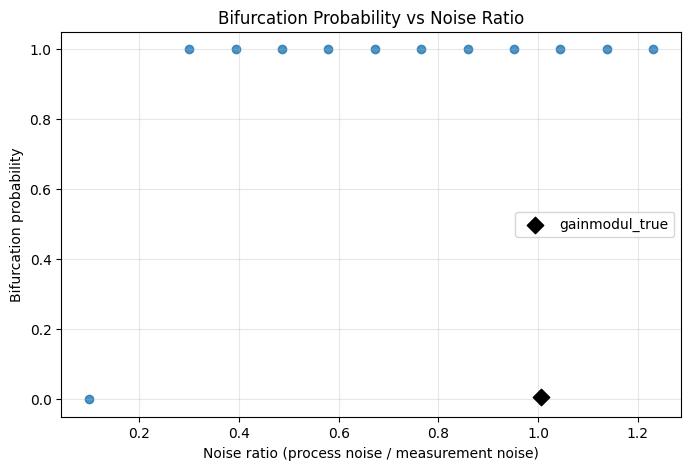

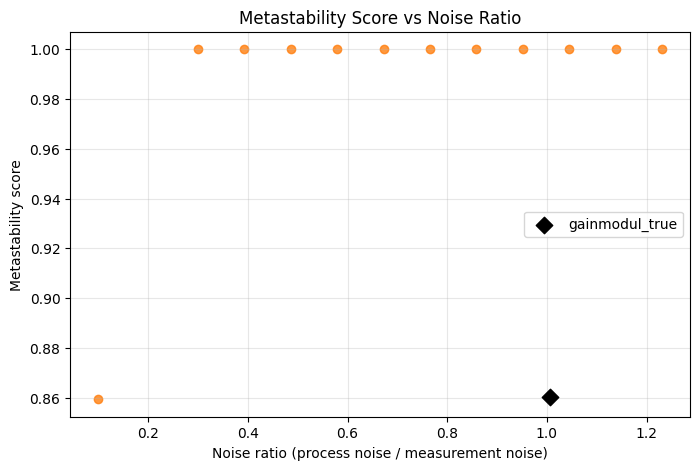

In [ ]:
# Reload the summary produced by the simulation loop
summary_path = cwd / "MeasureNoiseControl" / "metabifurc_control.csv"
control_df = pd.read_csv(summary_path)
control_df["noise_ratio"] = control_df["process_noise"] / control_df["measure_noise"]

#Reload the true model parameters for the specific participant
gainmodul_true = lead.model.StratifiedGainModulation(
    tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
param_path = Path(f'Fit_Active_late') / f"GainModulatedModel_part18_params"
gainmodul_true.load_params(param_path)
true_noise_ratio = gainmodul_true.process_noise / gainmodul_true.measure_noise

# Bifurcation probability as a function of the process/measurement noise ratio
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(control_df["noise_ratio"], control_df["probability_of_bifurcation"], alpha=0.8)
ax.scatter(
    true_noise_ratio,
    0.05,
    transform=ax.get_xaxis_transform(),
    marker="D",
    s=70,
    color="black",
    label="gainmodul_true",
    zorder=3,
)
ax.set_xlabel("Noise ratio (process noise / measurement noise)")
ax.set_ylabel("Bifurcation probability")
ax.set_title("Bifurcation Probability vs Noise Ratio")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

# Metastability score as a function of the process/measurement noise ratio
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(control_df["noise_ratio"], control_df["metastability_score"], alpha=0.8, color="tab:orange")
ax.scatter(
    true_noise_ratio,
    0.05,
    transform=ax.get_xaxis_transform(),
    marker="D",
    s=70,
    color="black",
    label="gainmodul_true",
    zorder=3,
)
ax.set_xlabel("Noise ratio (process noise / measurement noise)")
ax.set_ylabel("Metastability score")
ax.set_title("Metastability Score vs Noise Ratio")
ax.grid(alpha=0.3)
ax.legend()
plt.show()